# ΠΑΡΑΔΟΤΕΟ 1

## Ερώτημα α

In [ ]:
import numpy as np
from math import gamma, pi

In [ ]:
def true_vol(d):
  return (pi ** (d / 2)) / gamma(d / 2 + 1)

In [ ]:
N = 1_000_000
d = 2

while True:
    points = np.random.uniform(-1, 1, (N, d))

    distances_sq = np.sum(points**2, axis=1)

    hits = np.sum(distances_sq < 1.0)
    if hits == 0:
        break
    est_vol = (2**d) * (hits / N)
    actual_vol = true_vol(d)

    rel_error = abs(est_vol - actual_vol) / actual_vol

    print(f"{d:<4} | {est_vol:<18.5f} | {actual_vol:<18.5f} | {rel_error:.2%}")

    d += 1

2    | 3.13910            | 3.14159            | 0.08%
3    | 4.18643            | 4.18879            | 0.06%
4    | 4.93677            | 4.93480            | 0.04%
5    | 5.27597            | 5.26379            | 0.23%
6    | 5.16730            | 5.16771            | 0.01%
7    | 4.73600            | 4.72477            | 0.24%
8    | 4.05171            | 4.05871            | 0.17%
9    | 3.26861            | 3.29851            | 0.91%
10   | 2.35520            | 2.55016            | 7.65%
11   | 1.92307            | 1.88410            | 2.07%
12   | 1.26157            | 1.33526            | 5.52%
13   | 1.10592            | 0.91063            | 21.45%
14   | 0.62259            | 0.59926            | 3.89%
15   | 0.49152            | 0.38144            | 28.86%
16   | 0.06554            | 0.23533            | 72.15%
17   | 0.26214            | 0.14098            | 85.94%


## Ερώτημα β

In [ ]:
import matplotlib.pyplot as plt

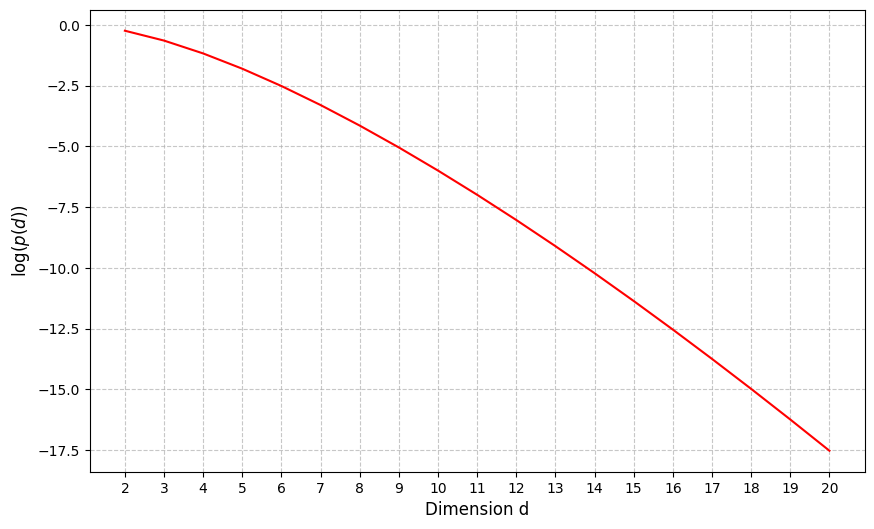

In [ ]:
dimensions = np.arange(2, 21)

p_d = [true_vol(d) / (2**d) for d in dimensions] # p(d) based on theory

log_p = np.log(p_d)

plt.figure(figsize=(10, 6))
plt.plot(dimensions, log_p, color='red')
plt.xlabel('Dimension d', fontsize=12)
plt.ylabel(r'$\log(p(d))$', fontsize=12)
plt.xticks(dimensions)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Καθώς η διάσταση d αυξάνεται, ο όγκος της μοναδιαίας μπάλας συρρικνώνεται δραματικά σε σχέση με τον περιβάλλοντα υπερκύβο. Γεωμετρικά, αυτό σημαίνει ότι σε μεγάλες διαστάσεις τα περισσότερα σημεία του μοναδιαίου κύβου βρίσκονται στις "γωνίες" του. Συνεπώς, η πιθανότητα p(d) να πέσει ένα τυχαία επιλεγμένο σημείο του υπερκύβου μέσα στη μπάλα τείνει ταχύτατα στο 0. Επειδή το σχετικό σφάλμα της μεθόδου Monte Carlo είναι ανάλογο του  1/sqrt(N*p(d)) όταν το p(d) μικραίνει απότομα, το σφάλμα της εκτίμησης πηγαίνει στο άπειρο. Αυτό το φαινόμενο, μας αποδεικνύει ότι η μέθοδος της δειγματοληψίας απόρριψης δεν μπορεί να εφαρμοστεί πρακτικά σε μεγάλες διαστάσεις.

## Ερώτημα γ

In [ ]:
import math

d = 20
target_samples = 1000

# Calculate the real vol of the ball for d = 20
vol_ball = (math.pi ** (d / 2)) / math.gamma(d / 2 + 1)

vol_cube = 2 ** d

p_20 = vol_ball / vol_cube

N_required = target_samples / p_20

Αν υποθέσουμε ρυθμό επεξεργασίας 10.000.000 δειγμάτων ανά δευτερόλεπτο που είναι τυπική απόδοση με numpy:

In [ ]:
samples_per_sec = 10_000_000
time_seconds = N_required / samples_per_sec
time_minutes = time_seconds / 60

print(f"p(20): {p_20:.2e}")
print(f"Required Samples N: {N_required:.2e}")
print(f"Estimated Time in my computer: {time_minutes:.2f} minutes")

p(20): 2.46e-08
Required Samples N: 4.06e+10
Estimated Time in my computer: 67.72 minutes


Για να συλλέξουμε 1000 δείγματα εντός της 20-διάστατης μοναδιαίας μπάλας με τη μέθοδο της απόρριψης, πρέπει να παραγάγουμε περίπου 40.6 δισεκατομμύρια σημεία. Στη θεωρία πιθανοτήτων, το πλήθος των δοκιμών μέχρι την επίτευξη ενός αριθμού επιτυχιών ακολουθεί  **αρνητική διωνυμική κατανομή**. Πιο συγκεκριμένα, ο  αναμενόμενος αριθμός συνολικών δοκιμών για 1000 επιτυχίες δίνεται από τον λόγο 1000 / p(20).

Από υπολογιστικής άποψης, η ζητούμενη  διαδικασία θα απαιτούσε πάνω από **67 λεπτά** συνεχούς επεξεργασίας. Αυτή η δραματική αύξηση της υπολογιστικής πολυπλοκότητας αποτελεί απόδειξη ότι σε χώρους υψηλών διαστάσεων, ο όγκος της μπάλας εκμηδενίζεται σε σχέση με τον υπερκύβο, αποδεικνύοντας ότι η μέθοδος της απόρριψης καθίσταται μη αποδοτική, όπως αναλύσαμε και στο προηγούμενο ερώτημα.

# ΠΑΡΑΔΟΤΕΟ 2

## Ερώτημα α

In [ ]:
import random as r

Φτιάχνω μια συνάρτηση όπου Παράγει δείγματα από τον μοναδιαίο δίσκο χρησιμοποιώντας MCMC. Αφήνουμε την αλυσίδα να κάνει  𝑁=100  βήματα πριν πάρουμε ένα δείγμα, ως προκαθορισμένο.

In [ ]:
def mcmc_disk(delta, N=100, samples=1000):
    point_x, point_y = [], []
    for _ in range(samples):
        x = [0.0, 0.0]
        R_sq = 0.0
        for _ in range(N):
            k = r.choice([0, 1])
            z = r.uniform(-delta, delta)
            x_prop_k = x[k] + z
            R_sqprop = R_sq - x[k]**2 + x_prop_k**2
            if R_sqprop < 1.0:
                R_sq = R_sqprop
                x[k] = x_prop_k
        point_x.append(x[0])
        point_y.append(x[1])
    return point_x, point_y

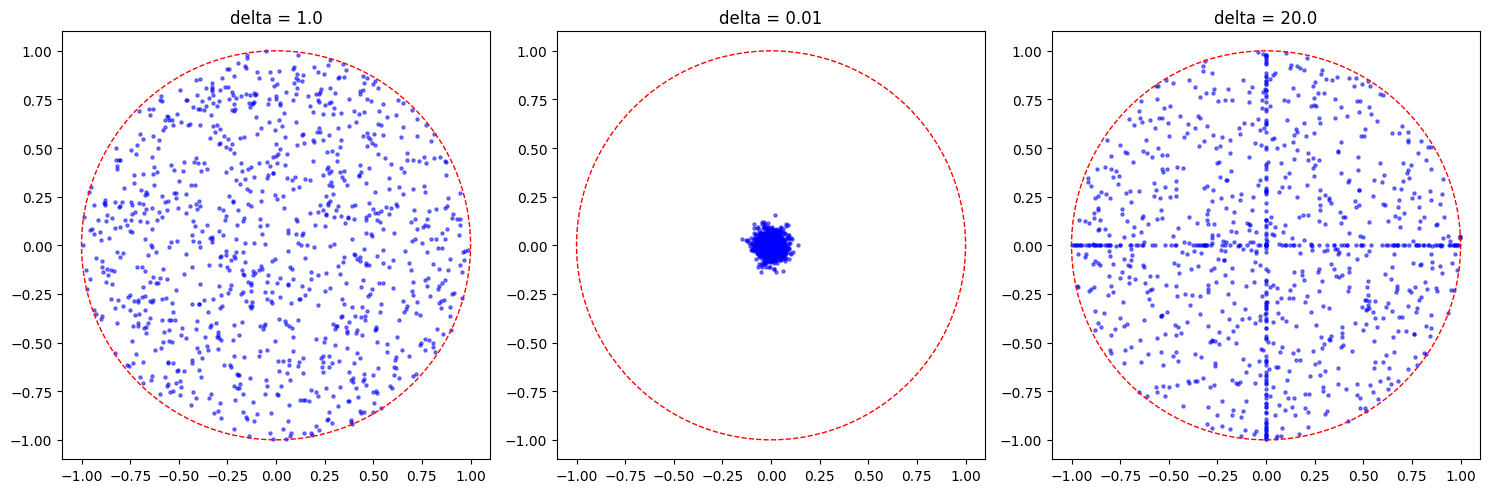

In [ ]:
deltas = [1.0, 0.01, 20.0]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, delta in enumerate(deltas):
    px, py = mcmc_disk(delta)

    # scatter plot
    axes[i].scatter(px, py, s=5, alpha=0.5, color='blue')

    circle = plt.Circle((0, 0), 1.0, color='red', fill=False, linestyle='--')
    axes[i].add_patch(circle)

    axes[i].set_title(f"delta = {delta}")
    axes[i].set_xlim(-1.1, 1.1)
    axes[i].set_ylim(-1.1, 1.1)
    axes[i].set_aspect('equal')

plt.tight_layout()
plt.show()

Η παράμετρος delta ελέγχει το μέγεθος του βήματος πρότασης  της Μαρκοβιανής αλυσίδας. Για να συγκλίνει η αλυσίδα στην αναλλοίωτη κατανομή και να εξερευνήσει σωστά τον χώρο όπως αναμένουμε, το delta πρέπει να είναι ισορροπημένο. Πιο συγκεκριμένα:

* delta = 0.01:
Το delta είναι υπερβολικά μικρό σε σχέση με την ακτίνα του δίσκου. Παρόλο που σχεδόν κάθε προτεινόμενο βήμα γίνεται αποδεκτό, η αλυσίδα κινείται υπερβολικά αργά. Για  **N=100**  βήματα, η αλυσίδα δεν προλαβαίνει να απομακρυνθεί από το σημείο εκκίνησης, με αποτέλεσμα όλα τα παραγόμενα δείγματα να συσσωρεύονται γύρω από το κέντρο (0,0). Η εξερεύνηση του χώρου είναι ανεπαρκής.

* delta = 20:
Το delta είναι πολύ μεγάλο σε σχέση με την ακτίνα του δίσκου. Ως επακόλουθο, σχεδόν κάθε νέα προτεινόμενη θέση πέφτει πολύ έξω από τα όρια του δίσκου  και απορρίπτεται. Το ποσοστό αποδοχής είναι κοντά στο 0%. Έτσι, η αλυσίδα παραμένει ακίνητη στην προηγούμενη κατάστασή της. Συνεπώς, στα **Ν = 100** βήματα η αλυσίδα συνήθως δεν μετακινείται επαρκώς  από το (0,0), παραμόνο σε κάποιες σπάνιες τροχές προς μόνο μια συνιστώσα. Όπως παρατηρούμε οπτικά, η αδυναμία των περισσότερων αλυσίδων να επιτύχουν έγκυρες μεταβάσεις και στις δύο διαστάσεις εντός των περιορισμένων βημάτων εξέλιξης, έχουν αποτέλεσμα να παραμένουν εγκλωβισμένες σε τροχιές όπου μόνο η μία συντεταγμένη μεταβάλλεται από την αρχική μηδενική τιμή της. (Για να "ξεφύγει" κάποια από τον άξονα x έχοντας κάνει ένα βήμα εκέι και να αποκτήσει συντεταγμένη y, πρέπει να πετύχει ένα έγκυρο βήμα και στον κάθετο άξονα, όπου το περιθώριο είναι ακόμα πιο στενό όσο αυξάνουμε/προχωράμε στη συνιστώσα x. Ομοίως και για το y)

## Ερώτημα β

Αν για κάθε διάσταση πάρουμε Ν = 100 :

In [ ]:
max_d = 100
samples = 5000
N_steps = 100

vols_est = np.zeros(max_d + 1)
vols_est[1] = 2.0  #  induction base ->  |D_1| = 2

for d in range(1, max_d):

    x = np.zeros((samples, d))
    r_sq = np.zeros(samples)

    # we adjust delta param in order to achieve better results, with N = 100 = const "mixing time"
    delta = max(1.0 / np.sqrt(d), 0.1)

    for _ in range(N_steps):
        k = np.random.randint(0, d, size=samples)

        z = np.random.uniform(-delta, delta, size=samples)

        old_xk = x[np.arange(samples), k]
        new_xk = old_xk + z

        new_r_sq = r_sq - old_xk**2 + new_xk**2

        accept = new_r_sq < 1.0 # a mask to check with vectorization the results.

        r_sq[accept] = new_r_sq[accept]
        x[np.arange(samples)[accept], k[accept]] = new_xk[accept]

    x_new = np.random.uniform(-1, 1, size=samples)
    hits = (r_sq + x_new**2) < 1.0
    ratio = np.sum(hits) / samples

    # induction step -> |D_{d+1}| = |D_d| * 2 * ratio
    vols_est[d+1] = vols_est[d] * 2 * ratio


    if (d+1) <= 10 or (d+1) % 10 == 0:
        actual = true_vol(d+1)
        err = abs(vols_est[d+1] - actual) / actual if actual > 0 else 0
        print(f"{d+1:<4} | {vols_est[d+1]:<20.5e} | {actual:<20.5e} | {err:.2%}")

2    | 3.13760e+00          | 3.14159e+00          | 0.13%
3    | 4.20940e+00          | 4.18879e+00          | 0.49%
4    | 4.98225e+00          | 4.93480e+00          | 0.96%
5    | 5.24133e+00          | 5.26379e+00          | 0.43%
6    | 5.19730e+00          | 5.16771e+00          | 0.57%
7    | 4.76904e+00          | 4.72477e+00          | 0.94%
8    | 4.07467e+00          | 4.05871e+00          | 0.39%
9    | 3.21573e+00          | 3.29851e+00          | 2.51%
10   | 2.50441e+00          | 2.55016e+00          | 1.79%
20   | 2.62886e-02          | 2.58069e-02          | 1.87%
30   | 4.33580e-05          | 2.19154e-05          | 97.84%
40   | 6.62073e-07          | 3.60473e-09          | 18266.79%
50   | 3.87020e-07          | 1.73022e-13          | 223682306.54%
60   | 2.76243e-06          | 3.09625e-18          | 89218555611627.88%
70   | 6.88138e-05          | 2.43228e-23          | 282919353901063110656.00%
80   | 3.52044e-03          | 9.42649e-29          | 3734621866238088

Στις **μεγάλες (>20) διαστάσεις**, με 100 βήματα η αλυσίδα δεν προλαβαίνει να απομακρυνθεί από το αρχικό σημείο (0,…,0). Τα δείγματα που εξάγουμε δεν είναι  ομοιόμορφα κατανεμημένα στη μπάλα, αλλά παραμένουν συγκεντρωμένα γύρω από την αρχή των αξόνων.

Αν επιπρόσθετα, επιλέγαμε να κλιμακώσουμε δυναμικά το N:

In [ ]:
for d in range(1, max_d):
    x = np.zeros((samples, d))
    r_sq = np.zeros(samples)

    delta = max(1.0 / np.sqrt(d), 0.1)

    # Dynamically change of N, based on the dimension d we are exploring.
    N_steps = 50 * d

    for _ in range(N_steps):
        k = np.random.randint(0, d, size=samples)
        z = np.random.uniform(-delta, delta, size=samples)

        old_xk = x[np.arange(samples), k]
        new_xk = old_xk + z

        new_r_sq = r_sq - old_xk**2 + new_xk**2

        accept = new_r_sq < 1.0

        r_sq[accept] = new_r_sq[accept]
        x[np.arange(samples)[accept], k[accept]] = new_xk[accept]

    x_new = np.random.uniform(-1, 1, size=samples)
    hits = (r_sq + x_new**2) < 1.0
    ratio = np.sum(hits) / samples

    vols_est[d+1] = vols_est[d] * 2 * ratio

    if (d+1) <= 10 or (d+1) % 10 == 0:
        actual = true_vol(d+1)
        err = abs(vols_est[d+1] - actual) / actual if actual > 0 else 0
        print(f"{d+1:<4} | {vols_est[d+1]:<20.5e} | {actual:<20.5e} | {err:.2%}")

2    | 3.10880e+00          | 3.14159e+00          | 1.04%
3    | 4.13097e+00          | 4.18879e+00          | 1.38%
4    | 4.93073e+00          | 4.93480e+00          | 0.08%
5    | 5.30744e+00          | 5.26379e+00          | 0.83%
6    | 5.28196e+00          | 5.16771e+00          | 2.21%
7    | 4.86152e+00          | 4.72477e+00          | 2.89%
8    | 4.22563e+00          | 4.05871e+00          | 4.11%
9    | 3.39741e+00          | 3.29851e+00          | 3.00%
10   | 2.60921e+00          | 2.55016e+00          | 2.32%
20   | 2.63377e-02          | 2.58069e-02          | 2.06%
30   | 2.36177e-05          | 2.19154e-05          | 7.77%
40   | 3.52552e-09          | 3.60473e-09          | 2.20%
50   | 1.82761e-13          | 1.73022e-13          | 5.63%
60   | 3.54695e-18          | 3.09625e-18          | 14.56%
70   | 2.88586e-23          | 2.43228e-23          | 18.65%
80   | 1.07942e-28          | 9.42649e-29          | 14.51%
90   | 2.88503e-34          | 1.96758e-34          | 

Παρατηρούμε πως το σφάλμα μειώθηκε δραματικά στις μεγάλες διαστάσεις, δίνοντας αρκετό χρόνο στην αλυσίδα να προχωρήσει και να καταλήξει στην αναλλοίωτη ομοιόμορφη κατανομή, ώστε να πάρουμε όσο το δυνατόν πιο ομοιόμορφα δείγματα.

In [ ]:
!jupyter nbconvert --to html lab6_ans.ipynb

[NbConvertApp] Converting notebook lab6_ans.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 508356 bytes to lab6_ans.html
